# UC2 — Results (reframed / corrected)

This supersedes `04_UC2_Results.ipynb`. Numbers come from the **final** runs under
`results/newpart` (client-local test) and `results/newpart_global` (global test)
via `uc2_honest_table.py` — **no retraining**. What changed and why:

| Issue (old notebook) | Fix here |
|---|---|
| Headline metric `unscaled_mae` lives in `10**(...)` space, is dominated by the largest-load samples, frozen w.r.t. real learning, and yields ~1e8 MAPE | Report the **scaled MSE/MAE** (computed directly on output vs y) |
| Read the superseded bare `results/` tree (where FedGen looked bad) | Read **`newpart` / `newpart_global`** |
| `fedgen-partial` had no data; "partial dominates" was unsupported | `newpart` has full 3-seed `fedgen-partial`; both protocols shown |

**Finding (corrected):** Centralized ≈ 0.032 > FedGen ≈ 0.040 ≫ FedAvg ≈ 0.17 — FedGen reaches near-centralized error and beats FedAvg ~4×.

**Caveats to state in the thesis:**
1. **FedAvg stalls — it does not diverge.** Its scaled MSE never improves on the round-0 init (best at round 0, even at α=10) while its L1 training objective (scaled MAE) decreases slowly and monotonically (≈0.39 → 0.34 over 300 rounds; no NaNs). L1 training pulls predictions toward the conditional median, which worsens MSE. The local-steps sweep (§3b) shows FedAvg does not escape at any `local_epochs` ∈ {1,5,10,20} while FedGen unlocks at ≥10 — the gap is a stability/efficiency property of the matched protocol, not an artifact of the le=20 choice.
2. **FedGen-partial** wins on the *client-local* test but degrades badly on the *global* test (personalization, not generalization) — see §4.
3. Model selection is on the test set (no validation split) — inherited, applied symmetrically.


In [8]:
import sys, os
sys.path.append('..')                       # so we can import uc2_honest_table.py
import uc2_honest_table as U
import pandas as pd, matplotlib.pyplot as plt
pd.set_option('display.width', 160); pd.set_option('display.max_columns', 30)
print('uc2_honest_table from:', U.BASE)
print('protocols:', {k: os.path.relpath(v, U.BASE) for k, v in U.PROTOCOLS.items()})


uc2_honest_table from: /mnt/c/Users/Marc/Documents/Uni/4t/TFG/Practices/Use Case 2
protocols: {'client_local': 'results/newpart', 'global': 'results/newpart_global'}


## 1. Load all results & export the CSV (both protocols)

In [9]:
df = U.build_dataframe()
csv_path = U.write_csv('uc2_results.csv', df=df)
print('CSV ->', csv_path, '|', len(df), 'rows')
df


CSV -> uc2_results.csv | 42 rows


,protocol,method,alpha,n_reps,best_mse,best_mse_std,last_mse,best_mae,last_mae,mse_improves,diverges
0,client_local,centralized,0.01,1,0.0308,0.0000,0.0322,0.0704,0.0722,True,False
1,client_local,centralized,0.10,1,0.0330,0.0000,0.0340,0.0734,0.0747,True,False
2,client_local,centralized,0.50,1,0.0325,0.0000,0.0341,0.0734,0.0744,True,False
3,client_local,centralized,1.00,1,0.0322,0.0000,0.0349,0.0723,0.0759,True,False
4,client_local,centralized,5.00,1,0.0324,0.0000,0.0349,0.0731,0.0753,True,False
5,client_local,centralized,10.00,1,0.0325,0.0000,0.0331,0.0730,0.0755,True,False
6,client_local,fedavg,0.01,3,0.1521,0.0003,0.1673,0.2813,0.2813,True,False
7,client_local,fedavg,0.10,3,0.1709,0.0004,0.2123,0.3357,0.3357,False,False
8,client_local,fedavg,0.50,3,0.1717,0.0004,0.2166,0.3394,0.3394,False,False
9,client_local,fedavg,1.00,3,0.1719,0.0004,0.2163,0.3394,0.3394,False,False


## 2. Accuracy vs heterogeneity (client-local, scaled MSE)

Lower = better. FedGen / FedGen-partial track Centralized; FedAvg sits ~4× higher
(it never improves on its init in MSE — a stall, see §3).

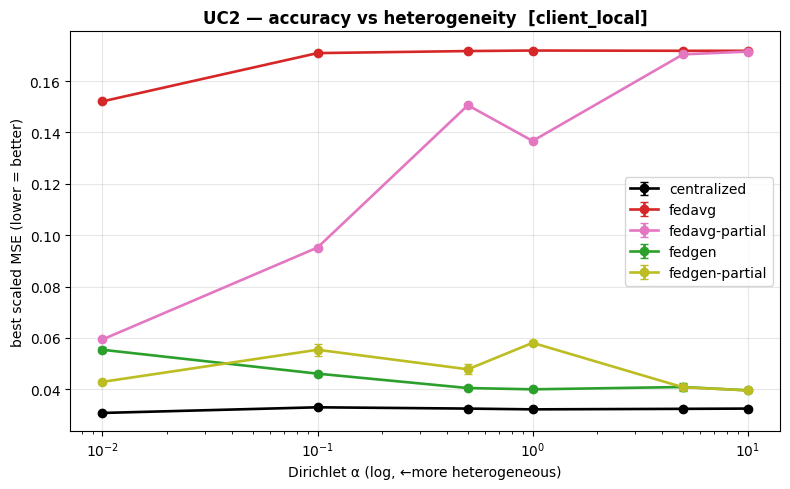

In [10]:
U.plot_mse_vs_alpha(df, 'client_local'); plt.show()


## 3. Convergence — FedAvg stalls vs FedGen converges

FedAvg's scaled MSE climbs and plateaus high (never beats its init) while its
scaled MAE — the L1 objective the clients actually optimize — decreases slowly
and monotonically: the baseline stalls, it does not diverge. FedGen converges
to ~0.04. §3b checks whether the stall is an artifact of the local-steps
setting (it is not).

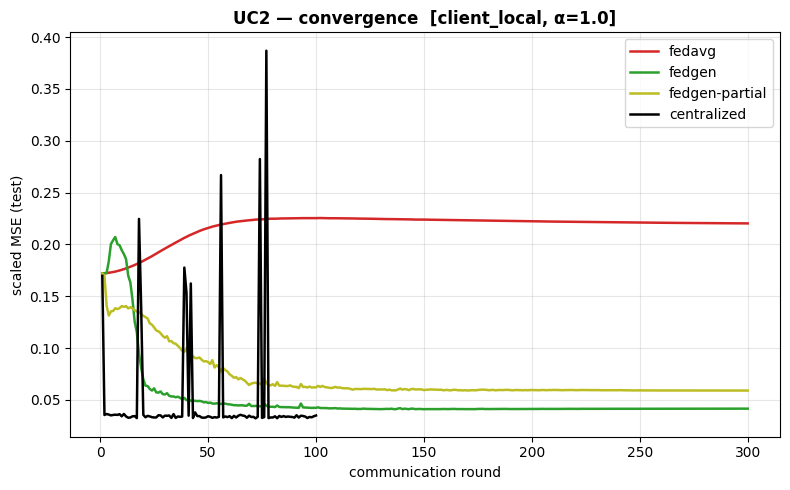

In [11]:
U.plot_convergence('client_local', alpha='1.0'); plt.show()


## 3b. Local-steps sweep — the stall is not a local-epochs artifact

`local_epochs` in this framework is the number of **mini-batch steps per round**
(K=1, batch 32), not full passes over the client data. Sweeping le ∈ {1, 5, 10}
against the le=20 baselines (seed 0, all six α):

* FedAvg improves monotonically with le (best scaled MAE 0.388 → 0.342 at α=1.0)
  — **more local steps help; there is no client-drift penalty** — but it never
  escapes the high-error regime at any le ≤ 20.
* FedGen is equally stuck at le ≤ 5 and unlocks at le ≥ 10 (MAE ≈ 0.15 → 0.10).
* Read the sweep on **MAE** (the trained objective). Best-MSE is uninformative
  here: FedAvg's best MSE is the untrained round-0 model, so its best-MSE row is
  flat across le by construction.

Caveats: single seed (rep_0); the fixed 300-round cap conflates le with total
compute (le=1 ⇒ 300 total steps vs 6 000 at le=20); fedgen-le5 early-stops
(~86–103 rounds). Artifacts: `uc2_le_sweep.csv` / `uc2_le_sweep.png`.

alpha       0.01    0.10    0.50    1.00    5.00    10.00
method le                                                
fedavg 1   0.3644  0.3862  0.3874  0.3879  0.3877  0.3877
       5   0.3195  0.3597  0.3618  0.3622  0.3622  0.3621
       10  0.2928  0.3463  0.3488  0.3491  0.3491  0.3492
       20  0.2836  0.3384  0.3417  0.3418  0.3425  0.3426
fedgen 1   0.3336  0.3703  0.3725  0.3743  0.3684  0.3696
       5   0.2899  0.3437  0.3466  0.3459  0.3477  0.3473
       10  0.1602  0.1482  0.1450  0.1470  0.1463  0.1545
       20  0.1308  0.1097  0.0987  0.0979  0.1022  0.0944

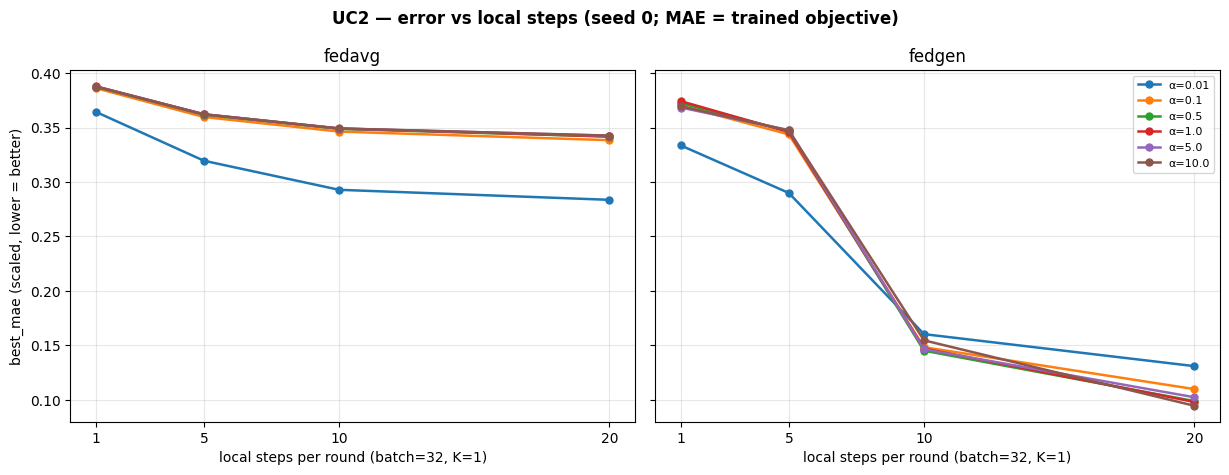

In [12]:
le = U.le_sweep_dataframe()
display(le.pivot_table(index=['method', 'le'], columns='alpha', values='best_mae').round(4))
U.plot_le_sweep(le); plt.show()

## 4. Client-local vs global test — the partial-sharing caveat

FedGen (full) generalizes to the global test; **FedGen-partial collapses** on the
global test at low α (personalization to local test, not true generalization).
Report partial's client-local numbers only alongside this.

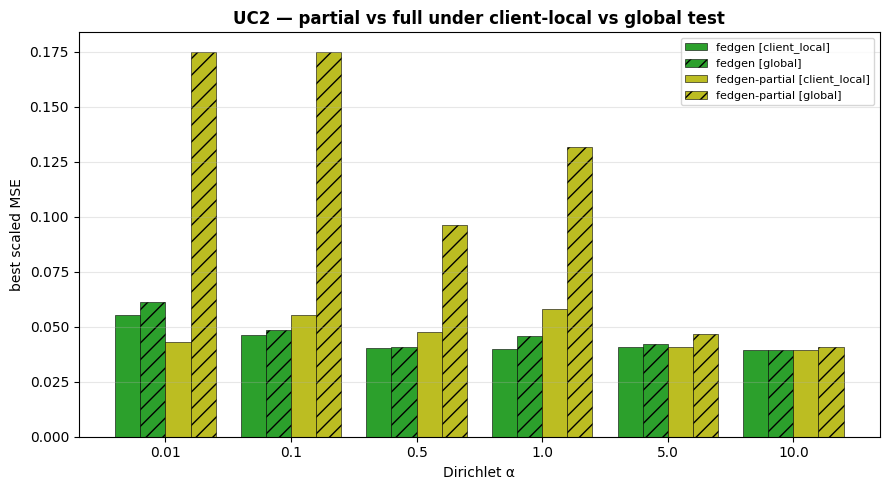

In [13]:
U.plot_local_vs_global(df); plt.show()


## 5. Summary table (client-local, best scaled MSE)

In [14]:
piv = (df[df.protocol == 'client_local']
       .pivot_table(index='method', columns='alpha', values='best_mse'))
display(piv.round(4))
print('Centralized < FedGen <= FedGen-partial << FedAvg at every alpha.')


alpha,0.01,0.10,0.50,1.00,5.00,10.00
method,,,,,,
centralized,0.0308,0.0330,0.0325,0.0322,0.0324,0.0325
fedavg,0.1521,0.1709,0.1717,0.1719,0.1718,0.1718
fedavg-partial,0.0594,0.0952,0.1506,0.1367,0.1704,0.1715
fedgen,0.0554,0.0461,0.0405,0.0400,0.0409,0.0396
fedgen-partial,0.0429,0.0554,0.0478,0.0581,0.0408,0.0396


Centralized < FedGen <= FedGen-partial << FedAvg at every alpha.


## 6. Limitations (state these explicitly in the thesis)

1. **Metric.** Scaled `mse`/RMSE (computed directly on output vs y) is the honest metric and is
   used throughout. `unscaled_mae`/`mape` live in `10**(...)` space (the target is log10),
   are dominated by the largest-load samples, are frozen w.r.t. real learning (≈0.4% range over
   300 rounds, r=−0.77 vs scaled error), and yield ~1e8 MAPE — they are **not** reported as a
   headline or used for model selection.
2. **FedAvg baseline.** Vanilla FedAvg *stalls* under the matched protocol: its scaled MSE never
   improves on the round-0 init (even at α=10) while its L1 objective improves slowly — a stall,
   not divergence (no NaNs; the trained loss decreases monotonically). The local-steps sweep (§3b;
   le ∈ {1,5,10,20}, seed 0) shows the stall is not a local-steps artifact: FedAvg does not escape
   at any le and more local steps help rather than hurt (no client-drift penalty), while FedGen
   unlocks at le ≥ 10. **Optimizer protocol:** all hyperparameters and optimizers follow the
   reference framework (Wilhelmi et al.) for comparability — FedAvg and FedGen use the *same* SGD
   optimizer and learning rate (the comparison is optimizer-matched), while the **centralized
   reference uses Adam** (hard-coded in the framework); the centralized–FL gap therefore crosses
   an optimizer boundary and is reported as an upper reference, not a matched baseline.
   Frame the FedAvg–FedGen gap as *stability/efficiency under the matched protocol*, not raw
   accuracy superiority. Note `local_epochs` = mini-batch steps per round (K=1, batch 32), not
   full epochs.
3. **Partial sharing keeps the encoder local**, so global-pool evaluation is **off-design** for
   FedGen-partial (local encoder applied to a shared global test, `new_partitions.py:174-191`).
   Client-local (`newpart`) is the **primary** metric for partial; the global result is reported
   as a stress test, not a fair benchmark.
4. **Communication cost.** Partial sharing exchanges only the head (`decode_fc2`). Sizes are now
   **measured from the instantiated objects** (UC2Utils.py): full LSTM 3.6331 MB (952,385 params),
   head 1.26e-4 MB (33 params), generator 0.0972 MB (25,472 params) — the paper constants
   (3.7 / 2e-3 / 0.113) overstated the head ≈16×. Head-only exchange is ≈28,800× cheaper than the
   full model; FedGen-partial costs ≈0.0975 MB/round/user (generator-dominated) vs 7.27 for full
   FedAvg (≈75×). Do not use the full-model cost for any partial variant on the Pareto, and re-run
   Pareto cells so they pick up the measured constants.
5. **Inherited from the reference (Zhu) framework.** (a) Model selection is on the **test** set
   (no validation split), applied symmetrically; (b) FedGen is a **classification** KD method
   adapted to **regression** — the generator's label-conditioning/diversity loss map imperfectly
   to a continuous target; this adaptation is acknowledged, not claimed as novel/validated.
6. **Replication.** `newpart_global` is single-seed and lacks FedAvg/centralized; the global
   FedGen-vs-FedAvg comparison is therefore incomplete.
7. **Evaluation data.** The per-user "test" sets are drawn from the held-out 20% *window-level*
   split of the same 100 training APs; consecutive sliding windows overlap (lookback 60, stride 1),
   so this measures held-out-window error, **not** generalization to unseen APs (the 16 unseen
   test APs produced by the dataset generator are not used). All methods share this protocol.